In [1]:
import os
import sys
import numpy as np
import xarray as xr
import pandas as pd
import geopandas as gpd
import shapely.vectorized as sv

from multiprocessing import Pool
from joblib import Parallel, delayed

import cartopy.crs as ccrs
import cartopy.feature as cfeature

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

sys.path.append(os.path.abspath("../.."))
from function import DOWN_raw
from function import ART_downscale

In [2]:
npix = 2
yy_s, yy_e = 2002, 2023
NEIBHR = 2*npix+1

In [3]:
product, time_reso = 'IMERG', '3h'
# product, time_reso = 'CMORPH', '3h'
# product, time_reso = 'MSWEP', '3h'
# product, time_reso = 'ERA5', '3h'
# product, time_reso = 'GSMaP', '3h'
# product, time_reso = 'CHIRPS', '1dy'

In [4]:
# PADOVA
# lon_min, lon_max, lat_min, lat_max, area = 11, 12.5, 45, 46, 'PADOVA'
# VENETO
lon_min, lon_max, lat_min, lat_max, area = 10.5, 13.5, 44.5, 47, 'VENETO'
# ITALY
# lon_min, lon_max, lat_min, lat_max, area = 6.5, 19, 36.5, 48, 'ITALY'

In [5]:
if area == 'PADOVA':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Padova.geojson'))
elif area == 'VENETO':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Veneto.geojson'))
elif area == 'ITALY':
    GEOMETRY = gpd.read_file(os.path.join('..','..', 'geometry','Italy_simple.geojson'))
else:
    sys.exit("Area not recognized. Please choose 'VENETO' or 'ITALY'.")

GEOMETRY_union = GEOMETRY.unary_union

/tmp/ipykernel_24140/726573604.py:10: DeprecationWarning: The 'unary_union' attribute is deprecated, use the 'union_all()' method instead.
  GEOMETRY_union = GEOMETRY.unary_union


In [6]:
dir_base = os.path.join('/','media','arturo','T9','Data','Italy','Satellite')
veneto_dir = os.path.join('/','media','arturo','T9','Data','shapes','Europa','Italy')

In [7]:
DEM =  gpd.read_file(os.path.join(veneto_dir,'DEM','Italy_dem_1000.geojson'))

In [8]:
if product == 'IMERG':
    filename = 'IMERG_Italy_3h_2001_01_01_2023_12_31.nc'

elif product == 'CMORPH':
    filename = 'CMORPH_Italy_3hr_1998_01_01_2023_12_31.nc'

elif product == 'MSWEP':
    filename = 'MSWEP_Italy_3h_1980_01_01_2023_12_31.nc'

elif product == 'ERA5':
    filename = 'ERA5_Italy_3h_2000_01_01_2023_12_31.nc'

elif product == 'GSMaP':
    filename = 'GSMaP_Italy_3h_2002_01_01_2024_12_31.nc'

elif product == 'CHIRPS':
    filename = 'CHIRPS_Italy_1dy_1981_01_01_2024_06_30.nc'

else:
    sys.exit('Product not found')

In [9]:
print(f'Product: {product}')
dir_input = os.path.join(dir_base,product,time_reso,filename)
DATA = xr.open_dataset(dir_input)
DATA = DATA.sel(time=DATA.time.dt.year.isin(np.arange(yy_s,yy_e+1)))
DATA = DATA.sel(lat=slice(lat_min-1.5, lat_max+1.5), lon=slice(lon_min-1.5, lon_max+1.5))
DATA = DATA.where(DATA>= -0.001)

lats = DATA['lat'].data
lons = DATA['lon'].data

lon2d, lat2d = np.meshgrid(lons, lats)
mask_study = sv.contains(GEOMETRY_union, lon2d, lat2d)

indices_lat, indices_lon = np.where(mask_study)

Product: IMERG


In [10]:
if product == 'IMERG':
    origin = [10, 3]
    target = [0, 24]

elif product == 'CMORPH':
    origin = [25, 3]
    target = [0, 24]

elif product == 'MSWEP':
    origin = [10, 3]
    target = [0, 24]

elif product == 'ERA5':
    origin = [25, 3]
    target = [0, 24]

elif product == 'GSMaP':
    origin = [10, 3]
    target = [0, 24]

elif product == 'CHRIPS':
    origin = [5, 24]
    target = [0, 24]

print(f'Product: {product}')
print(f'xscale : {origin[0]} km to {target[0]} km')
print(f'tscale : {origin[1]} hr to {target[1]} hr')

Product: IMERG
xscale : 10 km to 0 km
tscale : 3 hr to 24 hr


In [11]:
PRE_data_T = DATA.transpose('lon', 'lat', 'time')
time_vector_dt = pd.to_datetime(PRE_data_T['PRE']['time'].values)
DATA_3h = xr.DataArray(PRE_data_T['PRE'],  
                        coords={
                            'lon':PRE_data_T['lon'].values, 
                            'lat':PRE_data_T['lat'].values, 
                            'time':time_vector_dt},
                        dims=('lon', 'lat', 'time'))

In [12]:
def compute_for_point(args):
    DATA_3h, la, lo = args
    lat_c = lats[la]
    lon_c = lons[lo]
    box_3h = DOWN_raw.create_box_v2(DATA_3h, lat_c, lon_c, npix)
    # pwets, xscales, tscales = DOWN_raw.compute_pwet_xr(box_3h, 1, cube1size=npix, dt=3, tmax=96)  
    # beta_ = ART_downscale.compute_beta(pwets, origin, target, xscales, tscales)

    WET_MATRIX, xscales2, tscales2 = DOWN_raw.compute_pwet_xr_v2(box_3h, dt=3, npix=npix, thresh=1)
    beta_ = ART_downscale.compute_beta(WET_MATRIX, origin, target, xscales2, tscales2)

    res = DOWN_raw.Taylor_beta(WET_MATRIX, xscales2, tscales2, L1=10, target_x=0.001, target_t=24,
                    origin_x=10, origin_t=3, ninterp = 1000, plot=True)

    return la, lo, beta_, res['beta'], res['contour']

tasks = (
    (DATA_3h, la, lo)
    for la, lo in zip(indices_lat, indices_lon)
)

with Pool(processes=25) as pool:
    results = list(pool.imap(compute_for_point, tasks, chunksize=1))

BETA_INTERPOLATED = np.ones((len(lats), len(lons)))*np.nan
BETA_ZORZETO = np.ones((len(lats), len(lons)))*np.nan
contour_ = []
for la, lo, beta_, res_beta, res_contour in results:
    BETA_INTERPOLATED[la, lo] = beta_
    BETA_ZORZETO[la, lo] = res_beta
    contour_.append(res_contour)

/home/arturo/github/MEVD-downscaling/function/DOWN_raw.py:411: RankWarning: Polyfit may be poorly conditioned
  res = np.polyfit(Tvec[:2], xscales_km[:2], 1)
/home/arturo/github/MEVD-downscaling/function/DOWN_raw.py:411: RankWarning: Polyfit may be poorly conditioned
  res = np.polyfit(Tvec[:2], xscales_km[:2], 1)
/home/arturo/github/MEVD-downscaling/function/DOWN_raw.py:411: RankWarning: Polyfit may be poorly conditioned
  res = np.polyfit(Tvec[:2], xscales_km[:2], 1)
/home/arturo/github/MEVD-downscaling/function/DOWN_raw.py:411: RankWarning: Polyfit may be poorly conditioned
  res = np.polyfit(Tvec[:2], xscales_km[:2], 1)
/home/arturo/github/MEVD-downscaling/function/DOWN_raw.py:411: RankWarning: Polyfit may be poorly conditioned
  res = np.polyfit(Tvec[:2], xscales_km[:2], 1)
/home/arturo/github/MEVD-downscaling/function/DOWN_raw.py:411: RankWarning: Polyfit may be poorly conditioned
  res = np.polyfit(Tvec[:2], xscales_km[:2], 1)
/home/arturo/github/MEVD-downscaling/function/DOWN_r

In [13]:
BETA_xr = xr.Dataset(data_vars={
                    "BETA": (("lat","lon"), BETA_INTERPOLATED),
                    },
    coords={'lat': lats, 'lon': lons},
    attrs=dict(description=f"Beta for '{product}' in the '{area}' area bounded by longitudes {lon_min} to {lon_max} and box size '{NEIBHR}x{NEIBHR}'."))

BETA_xr.BETA.attrs["units"] = "dimensionless"
BETA_xr.BETA.attrs["long_name"] = "Itermittency function between two generic scales"
BETA_xr.BETA.attrs["origname"] = "Beta"

DOWN_out = os.path.join('..','output',f'{area}_Beta_{product}_{time_reso}_{yy_s}_{yy_e}_npix_{npix}.nc')
print(f'Export Data to {DOWN_out}')
# BETA_xr.to_netcdf(DOWN_out)

Export Data to ../output/VENETO_Beta_IMERG_3h_2002_2023_npix_2.nc


In [14]:
data_dir = os.path.join(dir_base,'2_MEV','uncorrected','OLD',f'ITALY_DOWN_{product}_{time_reso}_2002_2023_npix_2_thr_1_acf_mar_genetic_pearson.nc')
DATA = xr.open_dataset(data_dir)
lon2d_all, lat2d_all = np.meshgrid(DATA.lon, DATA.lat)

mask_italy = sv.contains(GEOMETRY_union, lon2d_all, lat2d_all)
BETA_old = DATA.BETA.where(mask_italy).values

# del DATA

Beta Interpolated: 0.28122630115439706
Beta Zorzetto    : 0.27405304690834986


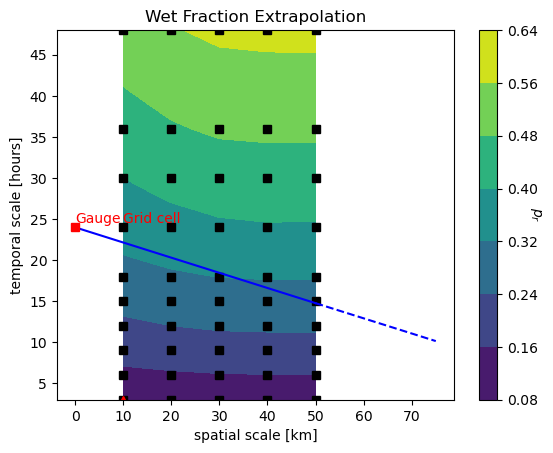

Beta Interpolated: 0.27965482180760276
Beta Zorzetto    : 0.26835526721230957


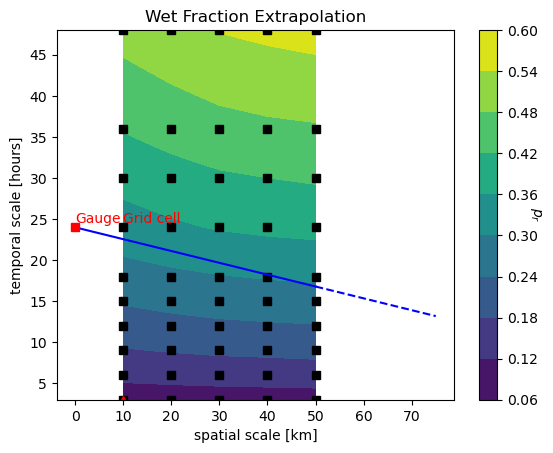

Beta Interpolated: 0.31943195443645084
Beta Zorzetto    : 0.299336398394368


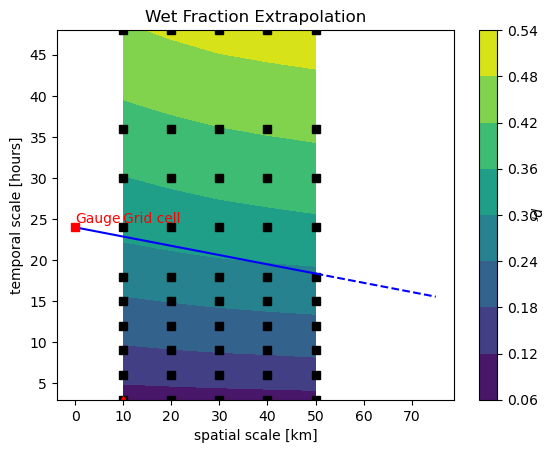

Beta Interpolated: 0.3197829637540046
Beta Zorzetto    : 0.2988748765833481


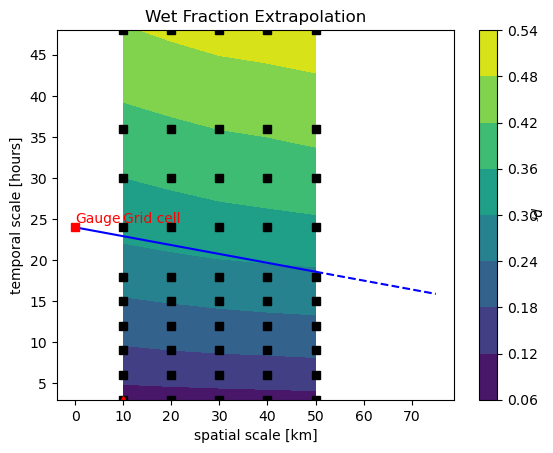

Beta Interpolated: 0.3179833112376199
Beta Zorzetto    : 0.2973616202950968


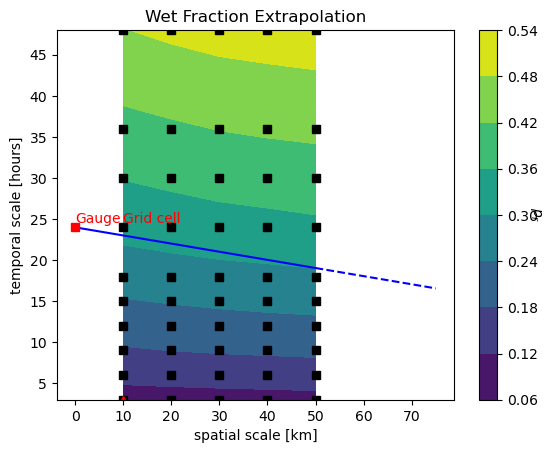

Beta Interpolated: 0.2893472233330667
Beta Zorzetto    : 0.2762539605571546


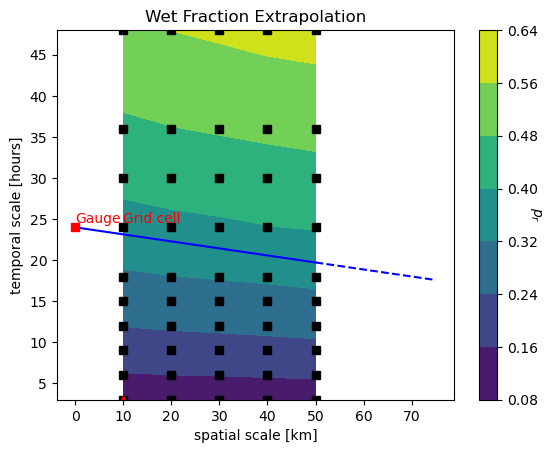

Beta Interpolated: 0.28519958976544707
Beta Zorzetto    : 0.27638555730452075


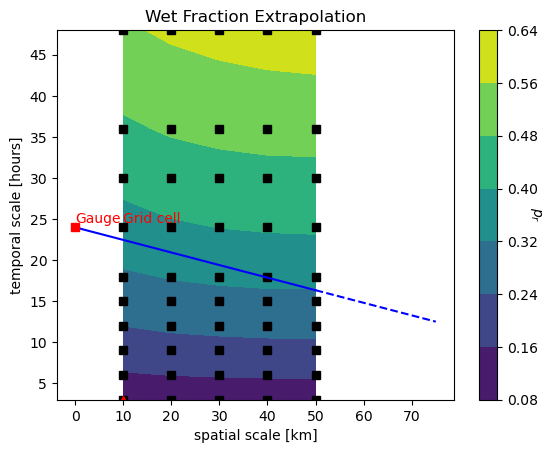

Beta Interpolated: 0.28192047856540897
Beta Zorzetto    : 0.2751584594409589


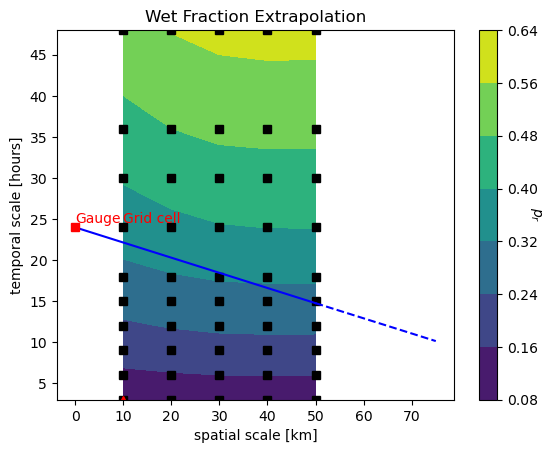

Beta Interpolated: 0.28049723515079006
Beta Zorzetto    : 0.26928840474974364


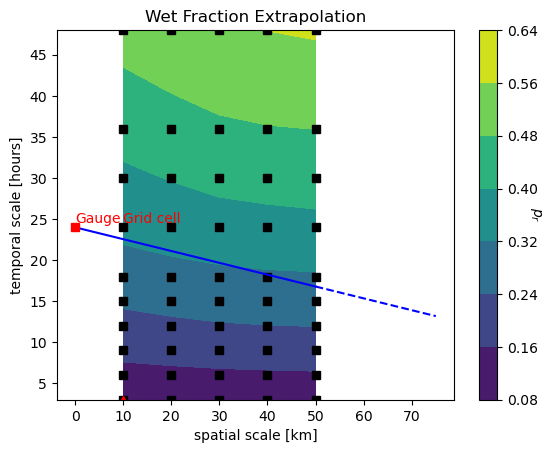

Beta Interpolated: 0.3202465240985133
Beta Zorzetto    : 0.297455477022394


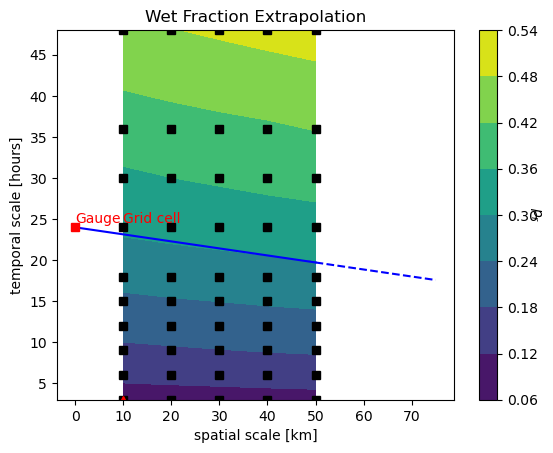

Beta Interpolated: 0.32098254109850904
Beta Zorzetto    : 0.2981385703324653


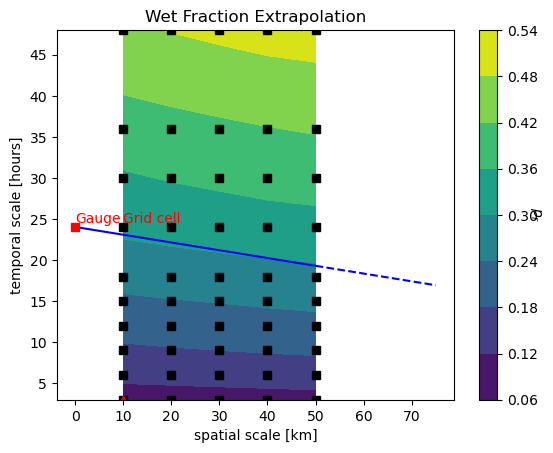

Beta Interpolated: 0.3197375701525571
Beta Zorzetto    : 0.29844213498651084


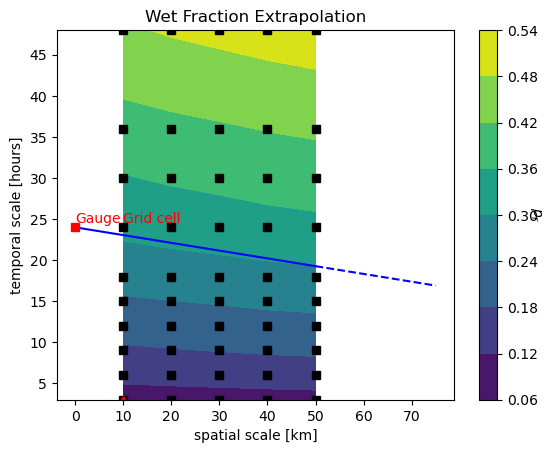

Beta Interpolated: 0.32023974054936943
Beta Zorzetto    : 0.2982312006345417


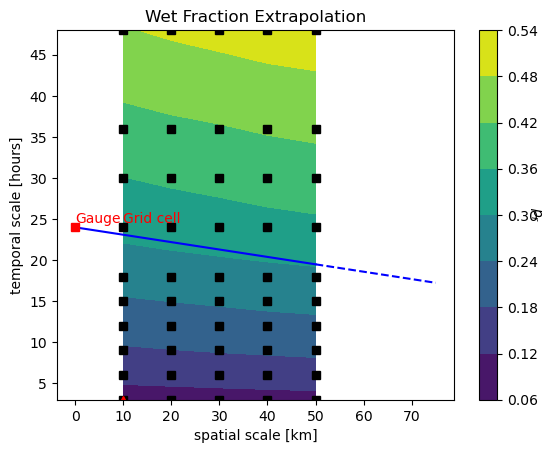

Beta Interpolated: 0.3185927458882475
Beta Zorzetto    : 0.2967469740870821


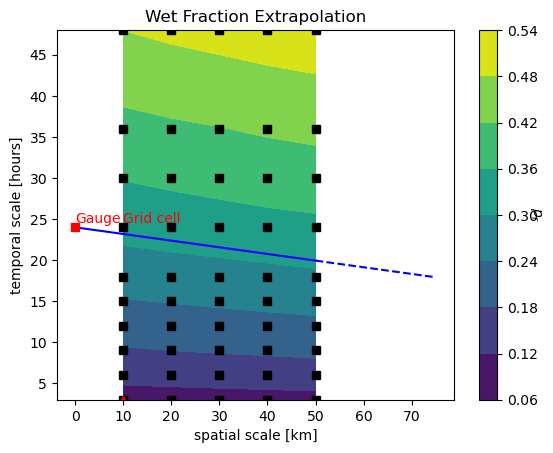

Beta Interpolated: 0.31795377720674833
Beta Zorzetto    : 0.29421816800239925


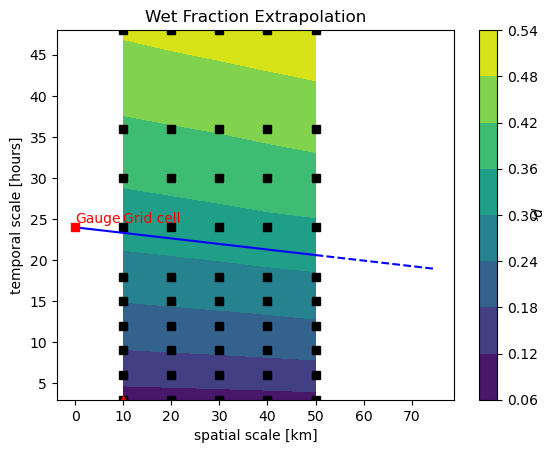

In [20]:
for nn in range(15):
    fig = results[nn][4]
    print(f'Beta Interpolated: {results[nn][2]}')
    print(f'Beta Zorzetto    : {results[nn][3]}')
    display(fig) 

Text(0.0, 1.0, 'Difference')

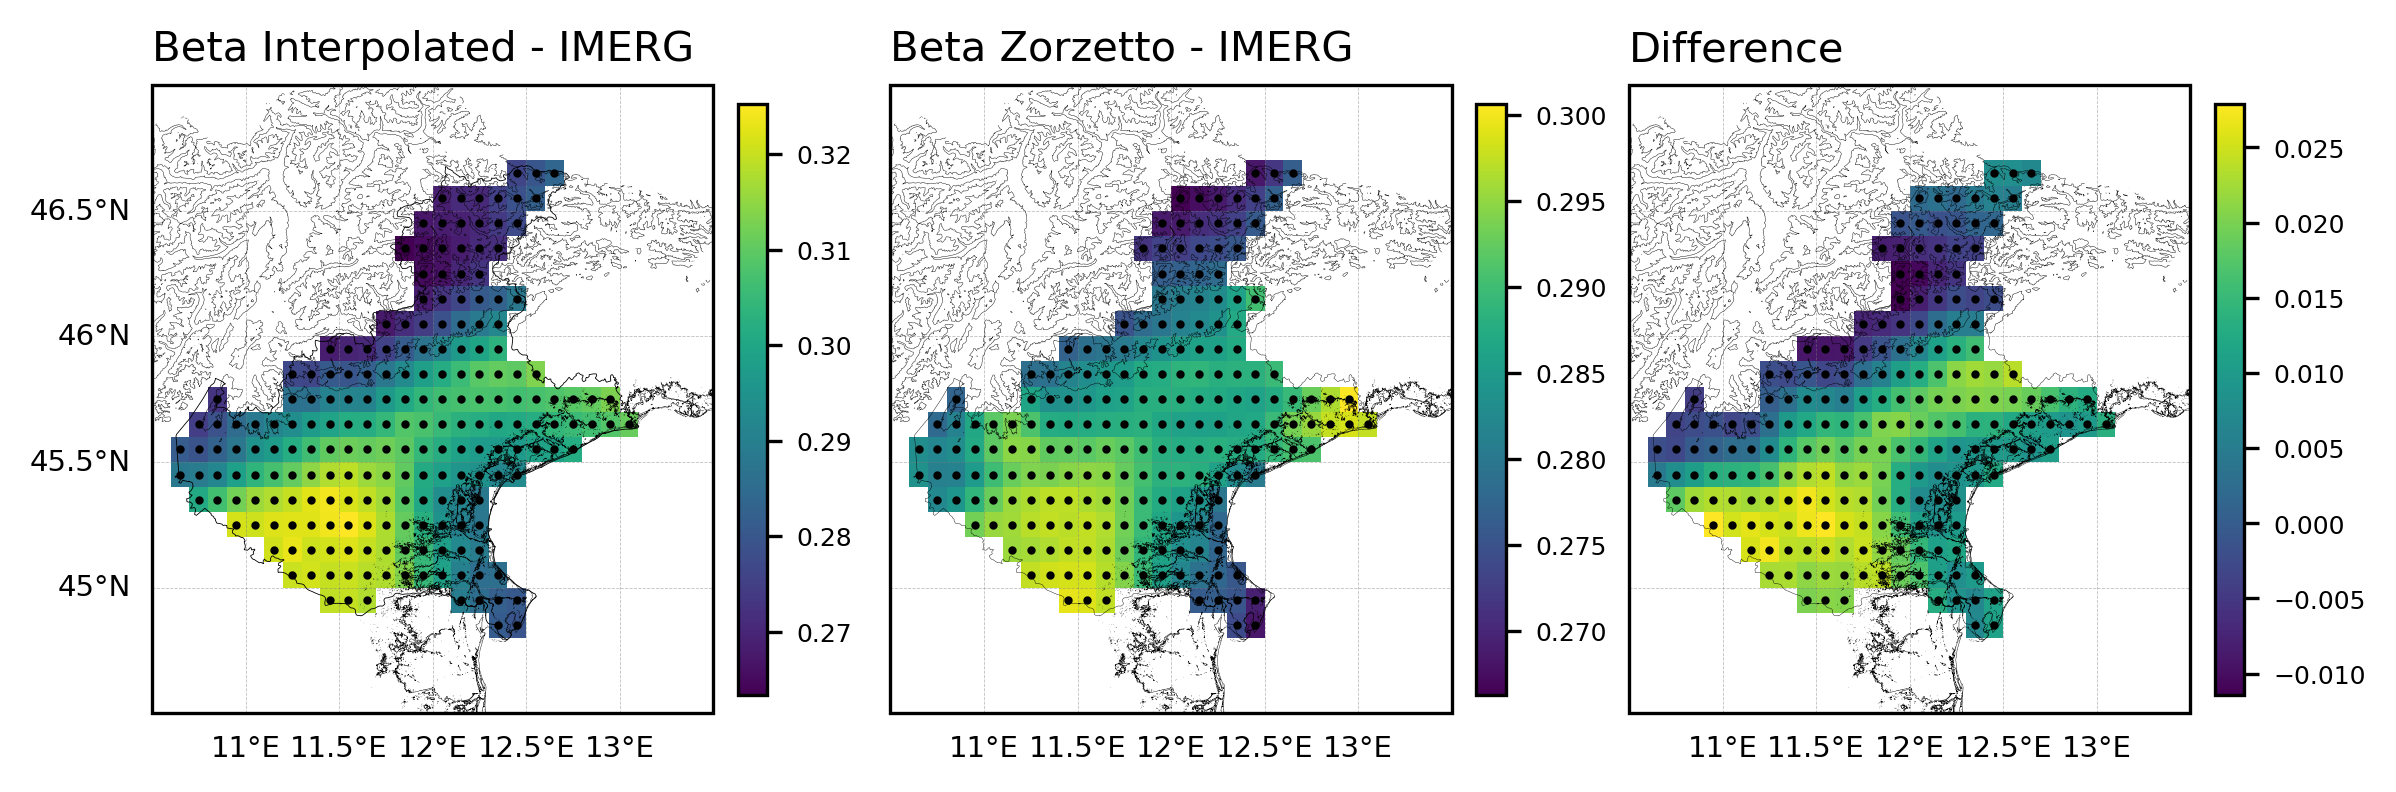

In [16]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(9,4),dpi=300)
gs = gridspec.GridSpec(1,3)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.2, ax=ax1, zorder=10)
DEM.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, BETA_INTERPOLATED)
cbar = plt.colorbar(a1, fraction=0.048, pad=0.04)
cbar.ax.tick_params(labelsize=6)

ax1.scatter(lons[indices_lon], lats[indices_lat], s=1, c='k', zorder=20)

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'k'}
gl.ylabel_style = {'size': 7, 'color': 'k'}

ax1.set_title(f'Beta Interpolated - {product}', fontsize=10, loc='left')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
DEM.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, BETA_ZORZETO)
cbar = plt.colorbar(a1, fraction=0.048, pad=0.04)
cbar.ax.tick_params(labelsize=6)

ax1.scatter(lons[indices_lon], lats[indices_lat], s=1, c='k', zorder=20)

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'k'}
gl.ylabel_style = {'size': 7, 'color': 'k'}

ax1.set_title(f'Beta Zorzetto - {product}', fontsize=10, loc='left')

# ========================================================================================================
ax1 = plt.subplot(gs[0, 2], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
DEM.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, BETA_INTERPOLATED-BETA_ZORZETO)
cbar = plt.colorbar(a1, fraction=0.048, pad=0.04)
cbar.ax.tick_params(labelsize=6)

ax1.scatter(lons[indices_lon], lats[indices_lat], s=1, c='k', zorder=20)

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = False
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'k'}
gl.ylabel_style = {'size': 7, 'color': 'k'}

ax1.set_title(f'Difference', fontsize=10, loc='left')

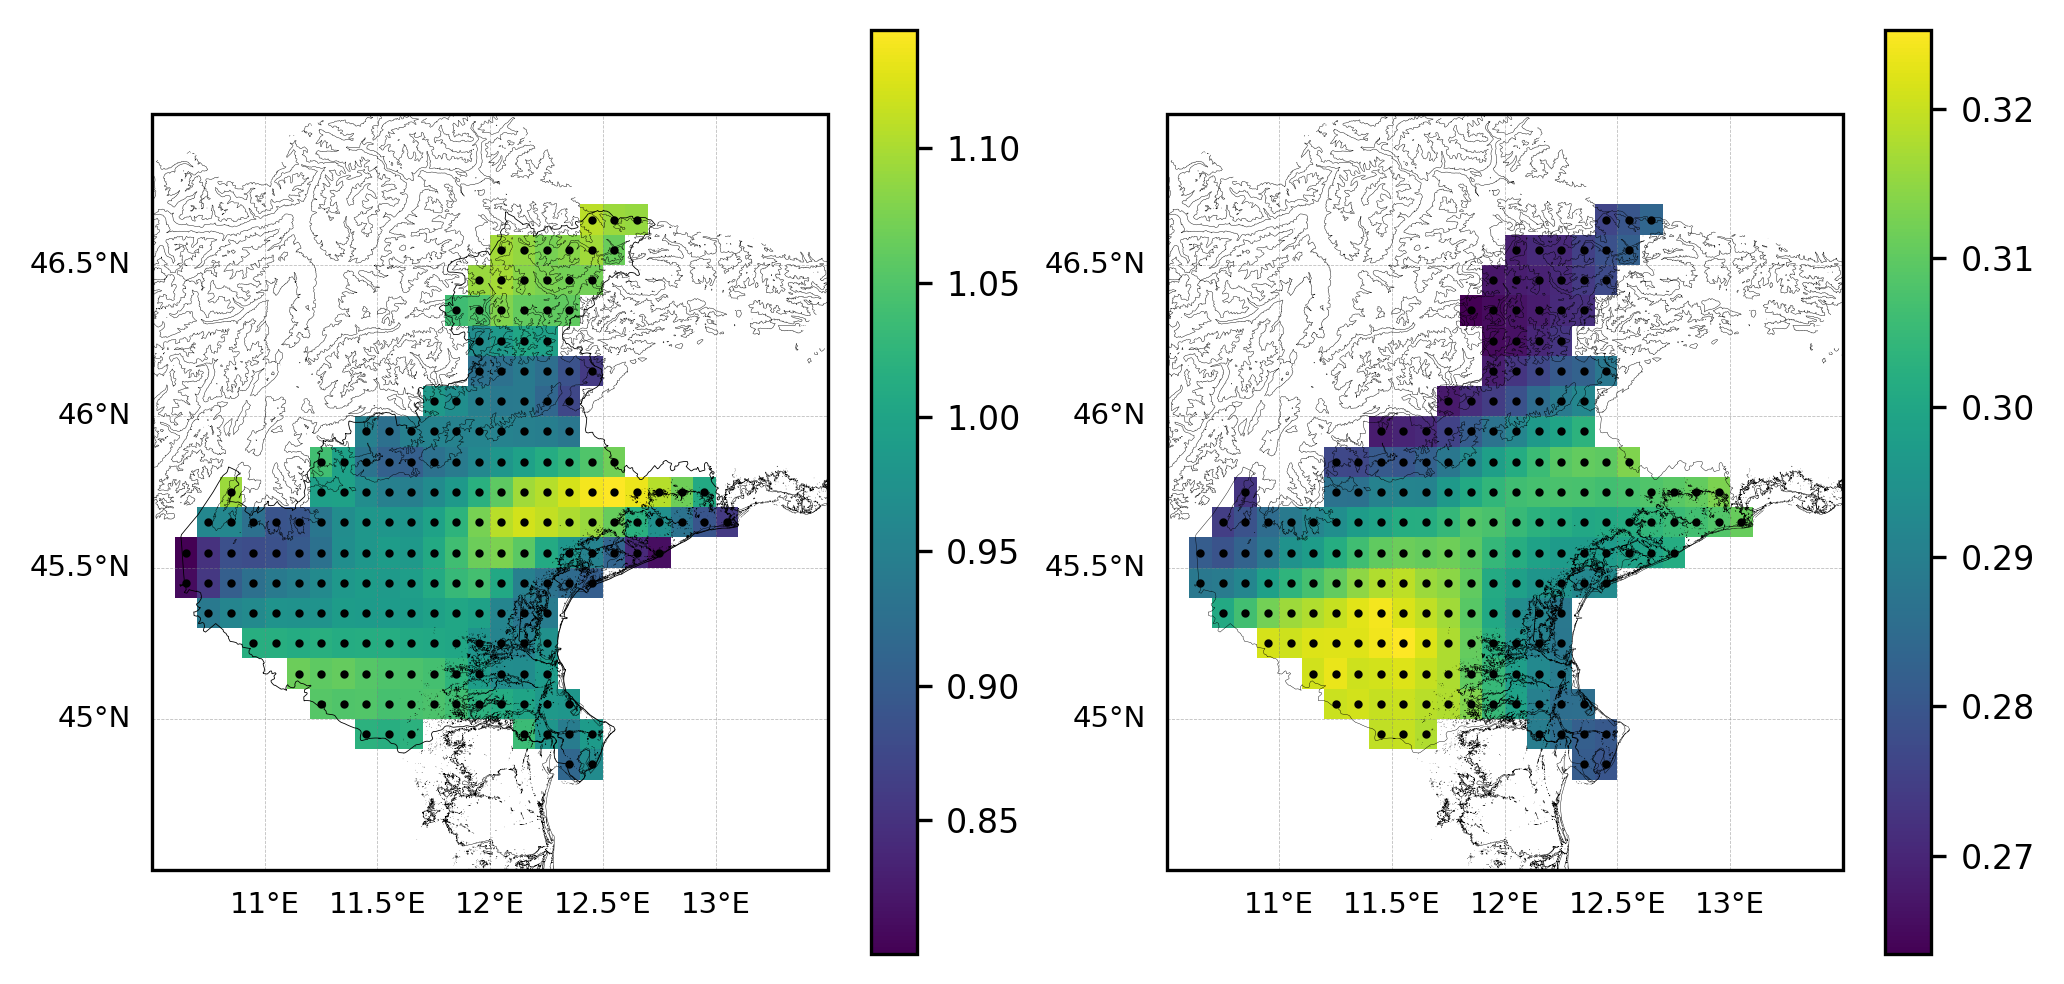

In [17]:
proj = ccrs.PlateCarree()

fig = plt.figure(figsize=(8,4),dpi=300)
gs = gridspec.GridSpec(1,2)

# ========================================================================================================
ax1 = plt.subplot(gs[0, 0], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.2, ax=ax1, zorder=10)
DEM.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d_all, lat2d_all, BETA_old)
cbar = plt.colorbar(a1)
cbar.ax.tick_params(labelsize=8)

ax1.scatter(lons[indices_lon], lats[indices_lat], s=1, c='k', zorder=20)

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'k'}
gl.ylabel_style = {'size': 7, 'color': 'k'}

# ========================================================================================================
ax1 = plt.subplot(gs[0, 1], projection = proj)
ax1.set_extent([lon_min, lon_max, lat_min, lat_max], crs=proj)
ax1.add_feature(cfeature.COASTLINE,linewidth=0.1,edgecolor='k')
GEOMETRY.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
DEM.plot(legend=False, facecolor="none", edgecolor='black', linewidth=0.1, ax=ax1, zorder=10)
a1 = ax1.pcolormesh(lon2d, lat2d, BETA_xr.BETA.values)
cbar = plt.colorbar(a1)
cbar.ax.tick_params(labelsize=8)

ax1.scatter(lons[indices_lon], lats[indices_lat], s=1, c='k', zorder=20)

gl = ax1.gridlines(crs=proj,draw_labels=True,linewidth=0.2,color='gray',alpha=0.5,linestyle='--')
gl.top_labels = False
gl.bottom_labels = True
gl.left_labels = True
gl.right_labels = False
gl.xlabel_style = {'size': 7, 'color': 'k'}
gl.ylabel_style = {'size': 7, 'color': 'k'}

In [18]:
sys.exit()

SystemExit: 

/home/arturo/anaconda3/envs/AXE/lib/python3.13/site-packages/IPython/core/interactiveshell.py:3585: UserWarning: To exit: use 'exit', 'quit', or Ctrl-D.
  warn("To exit: use 'exit', 'quit', or Ctrl-D.", stacklevel=1)


In [ ]:
def wetfrac(array, thresh):
        if len(array) == 0:
            return np.nan
        else:
            return np.size(array[array > thresh])/np.size(array)

def compute_pwet_xr_v2(box, dt, npix, thresh):
    tmax = 48
    smax = box.shape[0] # max spatial scale
    tscales = np.array([1, 2, 3, 4, 5, 6, 8, 10, 12, 16, 20, 24, 36, 48, 96])*dt
    tscales = tscales[tscales < tmax + 0.001]
    xscales = np.arange(1, smax+1)
    ntscales = np.size(tscales)
    nsscales = np.size(xscales)
    pwets = np.zeros((ntscales, nsscales))
    
    nlon = len(box['lon'].data)
    nlat = len(box['lat'].data)
    smax = box.shape[0]
    Swet_final = []

    for st in tscales:
        input_data = box.resample(time='{}h'.format(st)).sum(dim='time', skipna = False)

        for ix, sx in enumerate(xscales):
            if sx == 1:
                wet_tmp = np.zeros([nlon, nlat])
                for i in range(nlon):
                    for j in range(nlat):
                        wet_tmp[i,j] = wetfrac(input_data[i,j,:].data, thresh)
                Swet_final.append(np.nanmean(wet_tmp))

            elif sx == smax:
                rainfall_tmp = input_data.mean(axis=(0,1))
                wet_tmp = wetfrac(rainfall_tmp, thresh)
                Swet_final.append(np.nanmean(wet_tmp))

            elif sx > 1 and sx < smax:
                Swet_fraction = []
                # ================================================================================
                for i in range(nlon):
                    for j in range(nlat):
                        box_tmp = input_data[i:i+sx,j:j+sx,:]
                        if box_tmp.shape[0] == sx and box_tmp.shape[1] == sx:
                            wet_tmp = wetfrac(np.nanmean(box_tmp.data,axis=(0,1)), thresh)
                            Swet_fraction.append(wet_tmp)
                # ================================================================================
                # c1 = np.zeros(4)
                # c1[0] = wetfrac(input_data[:sx, :sx, :].mean(dim=('lat', 'lon'),
                #                 skipna=False).dropna(dim='time', how='any'),
                #                 thresh)
                # c1[1] = wetfrac(input_data[-sx:, :sx, :].mean(dim=('lat', 'lon'),
                #                 skipna=False).dropna(dim='time', how='any'),
                #                 thresh)
                # c1[2] = wetfrac(input_data[:sx, :sx, :].mean(dim=('lat', 'lon'),
                #                 skipna=False).dropna(dim='time', how='any'),
                #                 thresh)
                # c1[3] = wetfrac(input_data[-sx:, :sx, :].mean(dim=('lat', 'lon'),
                #                 skipna=False).dropna(dim='time', how='any'),
                #                 thresh)
                # Swet_fraction.append(np.mean(c1))
                # ================================================================================

                Swet_final.append(np.nanmean(Swet_fraction))

    WET_MATRIX = np.reshape(Swet_final, (len(tscales), len(xscales)))
    
    return WET_MATRIX, xscales, tscales


In [ ]:
lat_c = lats[indices_lat[0]]
lon_c = lons[indices_lon[0]]
box_3h = DOWN_raw.create_box_v2(DATA_3h, lat_c, lon_c, npix)
pwets, xscales, tscales = DOWN_raw.compute_pwet_xr(box_3h, 1, cube1size=npix, dt=3, tmax=48)

In [ ]:
WET_MATRIX, xscales2, tscales2 =compute_pwet_xr_v2(box_3h, dt=3, npix=npix, thresh=1)

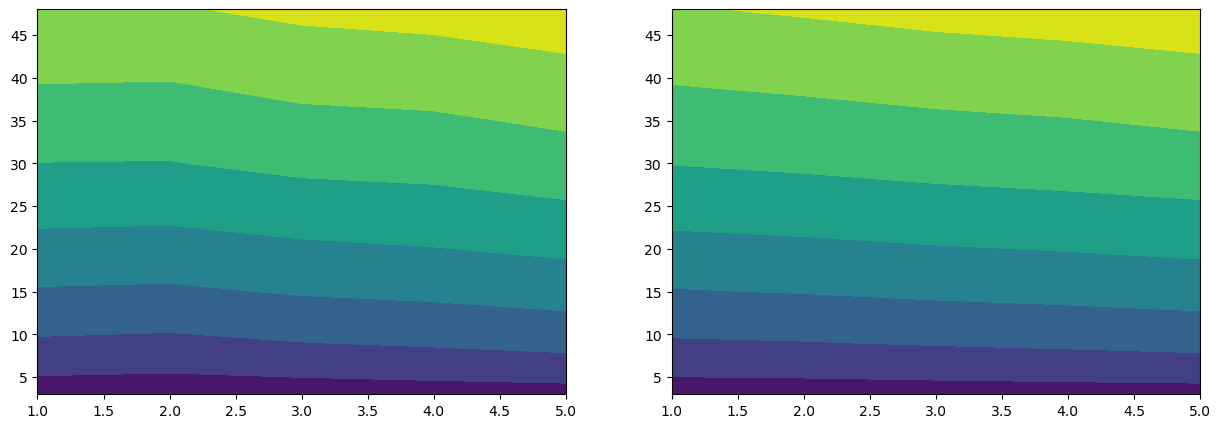

In [ ]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))

a1 = ax[0].contourf(xscales, tscales, pwets)

a2 = ax[1].contourf(xscales2, tscales2, WET_MATRIX)

In [ ]:
beta_1 = ART_downscale.compute_beta(pwets, origin, target, xscales, tscales)
beta_1

0.30254144743373373

In [ ]:
beta_2 = ART_downscale.compute_beta(WET_MATRIX, origin, target, xscales2, tscales2)
beta_2

0.30064677284422203

In [ ]:
res = DOWN_raw.Taylor_beta(WET_MATRIX, xscales2, tscales2, L1=10, target_x=0.001, target_t=24,
                    origin_x=10, origin_t=3, ninterp = 1000, plot=True)
res['beta']

/home/arturo/github/MEVD-downscaling/function/DOWN_raw.py:411: RankWarning: Polyfit may be poorly conditioned
  res = np.polyfit(Tvec[:2], xscales_km[:2], 1)
/home/arturo/github/MEVD-downscaling/function/DOWN_raw.py:411: RankWarning: Polyfit may be poorly conditioned
  res = np.polyfit(Tvec[:2], xscales_km[:2], 1)
/home/arturo/github/MEVD-downscaling/function/DOWN_raw.py:411: RankWarning: Polyfit may be poorly conditioned
  res = np.polyfit(Tvec[:2], xscales_km[:2], 1)
/home/arturo/github/MEVD-downscaling/function/DOWN_raw.py:411: RankWarning: Polyfit may be poorly conditioned
  res = np.polyfit(Tvec[:2], xscales_km[:2], 1)
/home/arturo/github/MEVD-downscaling/function/DOWN_raw.py:411: RankWarning: Polyfit may be poorly conditioned
  res = np.polyfit(Tvec[:2], xscales_km[:2], 1)
/home/arturo/github/MEVD-downscaling/function/DOWN_raw.py:411: RankWarning: Polyfit may be poorly conditioned
  res = np.polyfit(Tvec[:2], xscales_km[:2], 1)
/home/arturo/github/MEVD-downscaling/function/DOWN_r

0.2801656395596321

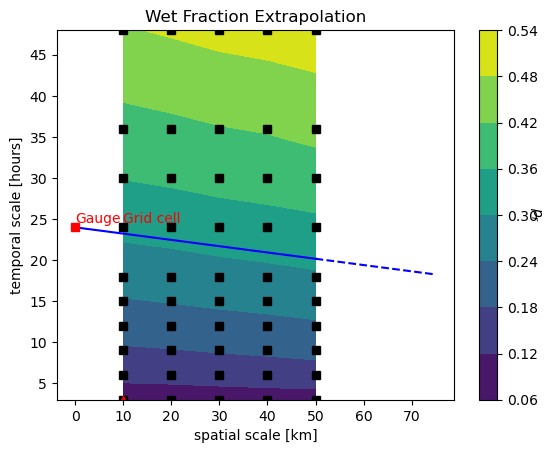

In [ ]:
res['contour']

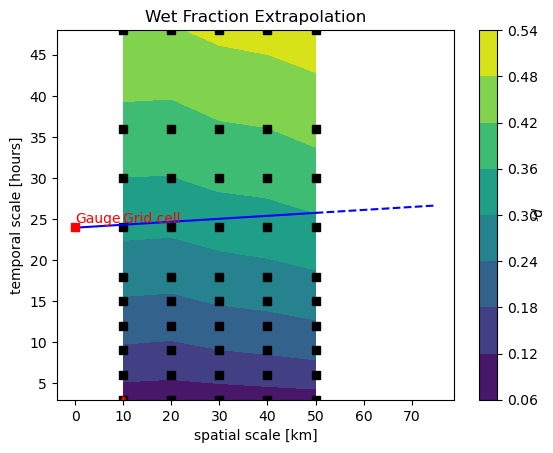

In [ ]:
res['contour']